In [111]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [112]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [113]:
df.shape

(8807, 12)

In [114]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [62]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [116]:
df.duplicated().sum()

np.int64(0)

In [117]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [118]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")

In [119]:
df["rating"] = df["rating"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")

In [120]:
df["date_added"] = pd.to_datetime(df["date_added"],errors="coerce")

In [121]:
df["date_added"].dtype

dtype('<M8[us]')

In [122]:
df["added_year"] = df["date_added"].dt.year

In [123]:
df[["date_added", "added_year"]].head()


,date_added,added_year
0,2021-09-25,2021.0
1,2021-09-24,2021.0
2,2021-09-24,2021.0
3,2021-09-24,2021.0
4,2021-09-24,2021.0


In [125]:
df.duplicated().sum()

np.int64(0)

In [144]:
df["date_added"] = df["date_added"].fillna("Unknown")
df["added_year"] = df["added_year"].fillna(0)

In [145]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
added_year      0
dtype: int64

In [146]:
type_counts = df["type"].value_counts()

type_counts

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

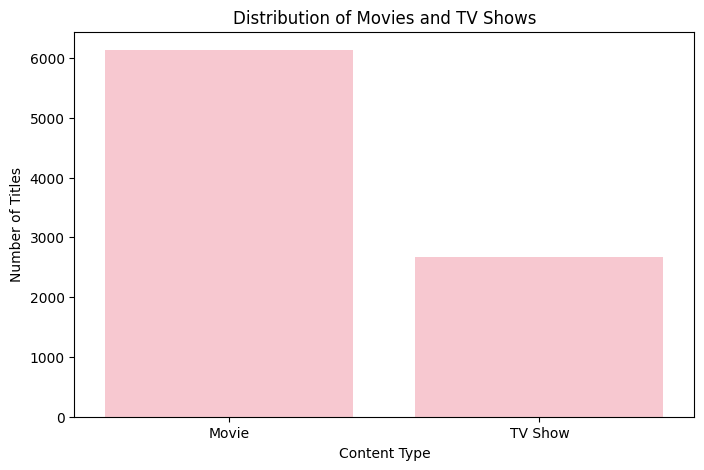

In [147]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="type",color="pink")

plt.title("Distribution of Movies and TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [148]:
year_count = df["added_year"].value_counts().sort_index()

year_count

added_year
0.0         98
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

In [150]:
year_count = df[df["added_year"] != 0]["added_year"].value_counts().sort_index()

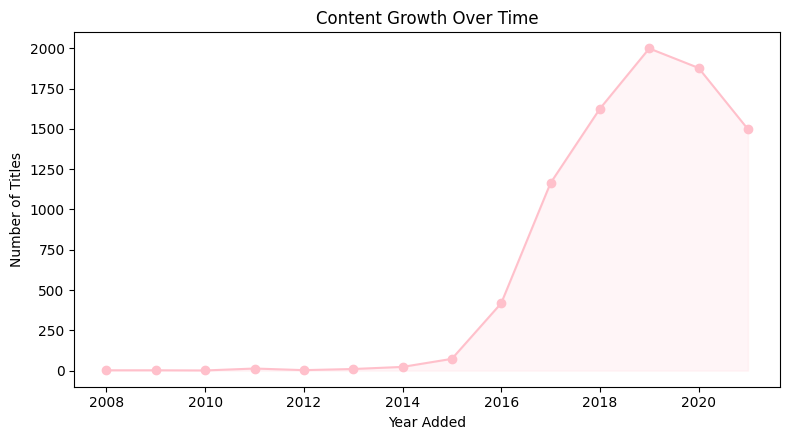

In [151]:
plt.figure(figsize=(8, 4.5))

plt.plot(
    year_count.index,
    year_count.values,
    marker='o',
    color='pink'
)

plt.fill_between(
    year_count.index,
    year_count.values,
    alpha=0.15,
    color='pink'
)

plt.title('Content Growth Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')

plt.tight_layout()
plt.show()

In [152]:
genres = df["listed_in"].dropna().str.split(", ").explode()

genre_count = genres.value_counts()

genre_count.head(10)


listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

In [153]:
top_genre = genre_count.head(10)

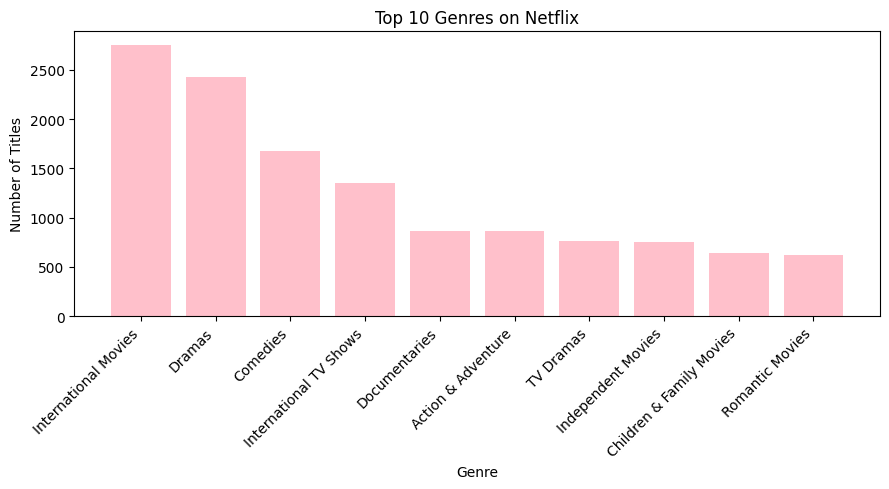

In [154]:
plt.figure(figsize=(9, 5))

plt.bar(top_genres.index, top_genres.values, color='pink')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Genre')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [155]:
top_years = df["release_year"].value_counts().head(10)

top_years

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

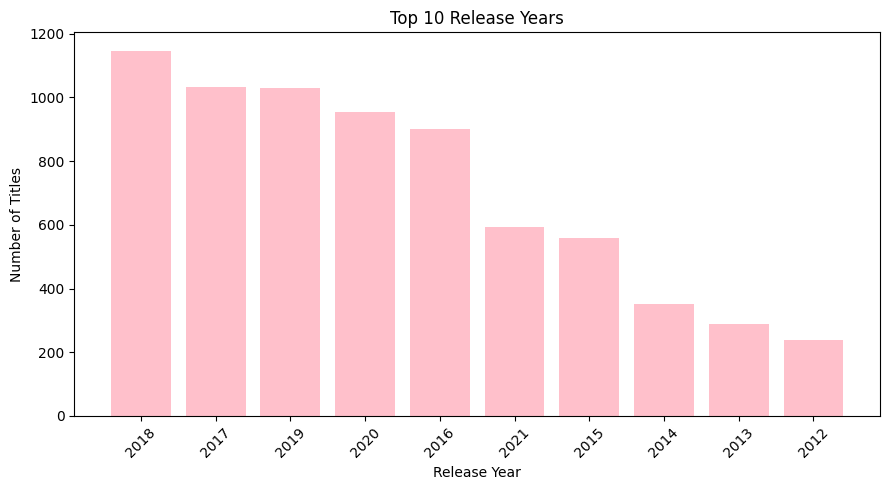

In [156]:
plt.figure(figsize=(9, 5))

plt.bar(
    top_years.index.astype(str),
    top_years.values,
    color='pink'
)

plt.title('Top 10 Release Years')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [157]:
rating_count = df["rating"].value_counts().head(10)

rating_count

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

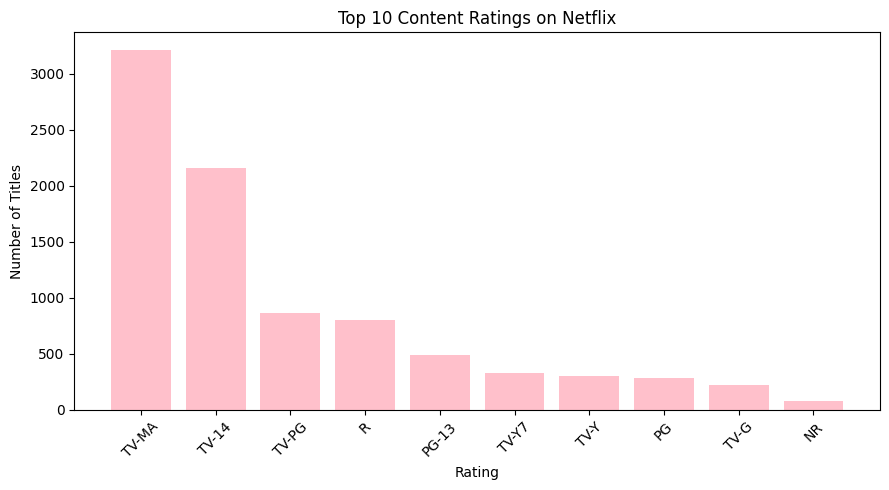

In [158]:
plt.figure(figsize=(9, 5))

plt.bar(
    rating_count.index,
    rating_count.values,
    color='pink'
)

plt.title('Top 10 Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [159]:
movies = df[df["type"] == "Movie"].copy()

movies["duration_minutes"] = (
    movies["duration"].str.extract("(\d+)").astype(float)
)

movies["duration_minutes"].describe()

<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\mahek lakha\AppData\Local\Temp\ipykernel_12456\3351770676.py:4: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  movies["duration"].str.extract("(\d+)").astype(float)


count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_minutes, dtype: float64

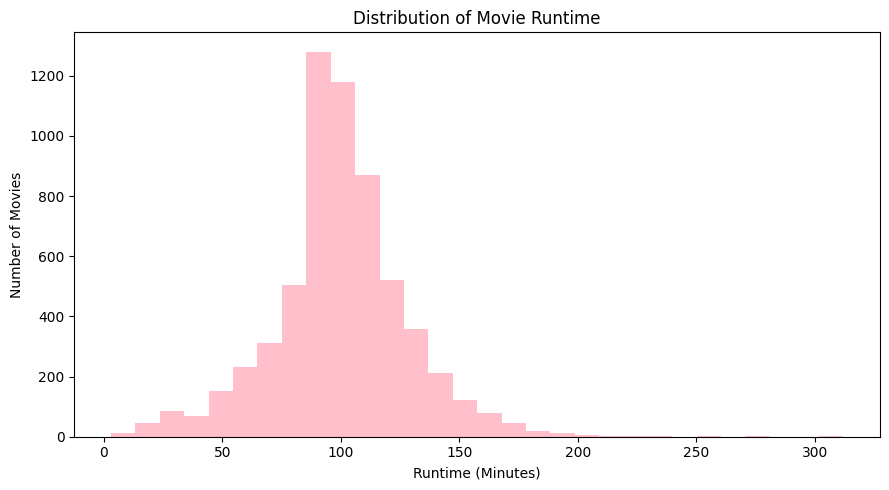

In [160]:
plt.figure(figsize=(9, 5))

plt.hist(
    movies["duration_minutes"].dropna(),
    bins=30,
    color='pink'
)

plt.title('Distribution of Movie Runtime')
plt.xlabel('Runtime (Minutes)')
plt.ylabel('Number of Movies')

plt.tight_layout()
plt.show()

In [165]:
df.to_csv("cleaned_netflix_data.csv", index=False)

# Conclusion

The Netflix dataset was successfully cleaned and analyzed using Python.
The analysis shows that Netflix contains more Movies than TV Shows.
The content library has grown significantly over the years.
The most common genres and content ratings were identified through exploratory data analysis.
The visualizations helped understand content distribution, growth trends, genres, release years, ratings, and movie runtime.
Overall, the analysis provides useful insights into Netflix's content library.